In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [10]:
df = pd.read_csv("../results/tuning_ga_new.csv")

In [11]:

best_configs = df.groupby(['N', 'k1', 'k2', 'beam_width']).agg({
    'objective': ['min', 'mean', 'median', 'max', 'std', 'count'],
    'duration': 'mean'
}).reset_index()

best_configs.columns = ['N', 'k1', 'k2', 'beam_width', 
                        'obj_min', 'obj_mean', 'obj_median', 'obj_max', 'obj_std', 'n_instances',
                        'avg_duration']

best_configs_sorted = best_configs.sort_values(['N', 'obj_mean'])

print("Top 3 Configs per N (by mean objective):")
for n in best_configs_sorted['N'].unique():
    print(f"\n=== N = {n} ===")
    print(best_configs_sorted[best_configs_sorted['N'] == n].head(3))

# Find overall best config per N
best_per_n = best_configs_sorted.groupby('N').first().reset_index()
print("\n✅ Best Config per N:")
print(best_per_n[['N', 'k1', 'k2', 'beam_width', 'obj_mean', 'obj_std', 'avg_duration']])


Top 3 Configs per N (by mean objective):

=== N = 50 ===
     N  k1  k2  beam_width  obj_min   obj_mean  obj_median  obj_max  \
17  50  15   2          10  897.786  1085.6252     1094.24  1270.99   
16  50  15   2           5  884.456  1108.5752     1134.44  1242.73   
15  50  15   1          10  912.869  1114.1158     1119.53  1243.66   

       obj_std  n_instances  avg_duration  
17  135.324125            5      7806.908  
16  134.392326            5      3853.004  
15  137.230655            5      9090.602  

=== N = 100 ===
      N  k1  k2  beam_width  obj_min  obj_mean  obj_median  obj_max  \
35  100  15   2          10  2879.48  3102.084     3023.27  3543.10   
34  100  15   2           5  2908.85  3150.352     3115.93  3553.03   
33  100  15   1          10  2953.21  3159.914     3087.09  3479.19   

       obj_std  n_instances  avg_duration  
35  257.719528            5      26487.28  
34  247.482930            5      13375.64  
33  206.851949            5      28706.52  

===

/tmp/ipykernel_40746/4143982753.py:50: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40746/4143982753.py:50: UserWarning: Glyph 129352 (\N{SECOND PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40746/4143982753.py:50: UserWarning: Glyph 129353 (\N{THIRD PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40746/4143982753.py:50: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40746/4143982753.py:51: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.savefig('top3_ga_configs.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_40746/4143982753.py:51: UserWarning: Glyph 129352 (\N{SECOND PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.savefig('top3_ga_configs.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_40746/4143982753.py:51: UserWarning: G

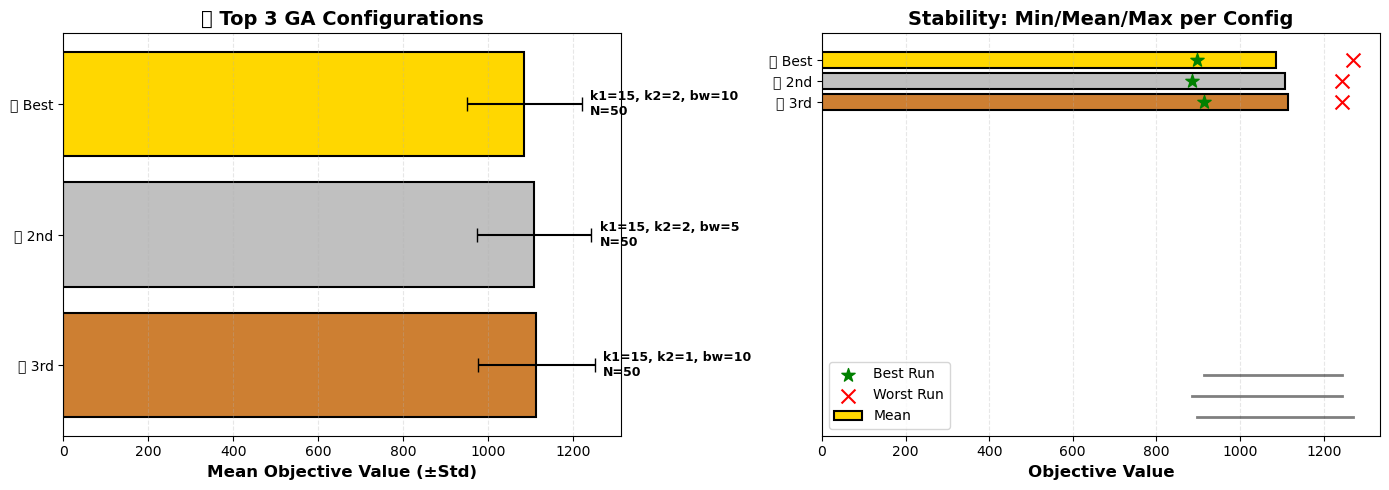


🏆 TOP 3 GENETIC ALGORITHM CONFIGURATIONS 🏆
  rank  N  k1  k2  beam_width  obj_mean    obj_std  obj_min  obj_max
🥇 Best 50  15   2          10 1085.6252 135.324125  897.786  1270.99
 🥈 2nd 50  15   2           5 1108.5752 134.392326  884.456  1242.73
 🥉 3rd 50  15   1          10 1114.1158 137.230655  912.869  1243.66

✅ RECOMMENDED CONFIG:
   N=50, k1=15, k2=2, beam_width=10
   Mean Objective: 1085.63 ± 135.32
   Best Run: 897.79 | Worst Run: 1270.99


In [12]:
configs = df.groupby(['N', 'k1', 'k2', 'beam_width']).agg({
    'objective': ['mean', 'std', 'min', 'max', 'count']
}).reset_index()

configs.columns = ['N', 'k1', 'k2', 'beam_width', 'obj_mean', 'obj_std', 'obj_min', 'obj_max', 'n_runs']

# Create config label for plotting
configs['config'] = configs.apply(lambda x: f"k1={int(x['k1'])}, k2={int(x['k2'])}, bw={int(x['beam_width'])}", axis=1)

# Sort by mean objective and get top 3
top3 = configs.nsmallest(3, 'obj_mean').copy()
top3['rank'] = ['🥇 Best', '🥈 2nd', '🥉 3rd']

# === PLOT: Top 3 Configs ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Mean Objective with Error Bars
ax1.barh(top3['rank'], top3['obj_mean'], xerr=top3['obj_std'], 
         color=['gold', 'silver', '#CD7F32'], edgecolor='black', linewidth=1.5, capsize=5)
ax1.set_xlabel('Mean Objective Value (±Std)', fontsize=12, fontweight='bold')
ax1.set_title('🏆 Top 3 GA Configurations', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Add config labels
for i, row in top3.iterrows():
    ax1.text(row['obj_mean'] + row['obj_std'] + 20, row['rank'], 
             f"{row['config']}\nN={int(row['N'])}", 
             va='center', fontsize=9, fontweight='bold')

# Plot 2: Min/Mean/Max Range
positions = range(len(top3))
ax2.barh(positions, top3['obj_mean'], color=['gold', 'silver', '#CD7F32'], 
         edgecolor='black', linewidth=1.5, label='Mean')
ax2.scatter(top3['obj_min'], positions, color='green', s=100, zorder=3, label='Best Run', marker='*')
ax2.scatter(top3['obj_max'], positions, color='red', s=100, zorder=3, label='Worst Run', marker='x')

# Error bars showing range
for i, row in top3.iterrows():
    ax2.plot([row['obj_min'], row['obj_max']], [i, i], 'k-', linewidth=2, alpha=0.5)

ax2.set_yticks(positions)
ax2.set_yticklabels(top3['rank'])
ax2.set_xlabel('Objective Value', fontsize=12, fontweight='bold')
ax2.set_title('Stability: Min/Mean/Max per Config', fontsize=14, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('top3_ga_configs.png', dpi=300, bbox_inches='tight')
plt.show()

# === OUTPUT TABLE ===
print("\n" + "="*80)
print("🏆 TOP 3 GENETIC ALGORITHM CONFIGURATIONS 🏆")
print("="*80)
print(top3[['rank', 'N', 'k1', 'k2', 'beam_width', 'obj_mean', 'obj_std', 'obj_min', 'obj_max']].to_string(index=False))
print("="*80)

# Best config for deployment
best = top3.iloc[0]
print(f"\n✅ RECOMMENDED CONFIG:")
print(f"   N={int(best['N'])}, k1={int(best['k1'])}, k2={int(best['k2'])}, beam_width={int(best['beam_width'])}")
print(f"   Mean Objective: {best['obj_mean']:.2f} ± {best['obj_std']:.2f}")
print(f"   Best Run: {best['obj_min']:.2f} | Worst Run: {best['obj_max']:.2f}")
